# Code Demonstration for Group Project

## Necessary imports

In [1]:
# Necessary Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Libraries for Multicollinearity and Factor Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Libraries for Time Series Analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Libraries for Econometrics Modeling
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

## Step 1: Data Loading, Assembly, and Cleaning

1. PanelDataProcessor: Loads the raw World Bank and OWID CSVs, standardizes the country codes, and merges them into a single raw panel dataset.

Output: Merged_Sustainable_Energy_Panel.csv

2. PanelDataCleaner: Filters the dataset to your desired timeframe (e.g., 2012–2021), trims down to your 18 variables of interest, and mathematically imputes the missing values so you have a perfectly balanced panel.

Outputs: Cleaned_Analysis_Ready_Panel.csv

In [2]:
from utils import PanelDataProcessor as PDP

In [3]:
processor = PDP(
    wb_path='../data/WorldBank.csv', 
    owid_path='../data/OWID.csv'
)

final_df = processor.run_pipeline(output_filename='Merged_Sustainable_Energy_Panel.csv')

Cleaning World Bank dataset...
World Bank dataset cleaned. Shape: (3990, 11)
Cleaning OWID dataset...
OWID dataset cleaned. Shape: (17134, 130)
Merging datasets into a panel...
Panel dataset successfully created! Shape: (18291, 138)
Data saved to Merged_Sustainable_Energy_Panel.csv


In [4]:
from utils import PanelDataCleaner as PDC

In [5]:
cleaner = PDC(input_filepath='Merged_Sustainable_Energy_Panel.csv')

final_clean_df = cleaner.run_cleaning_pipeline(
        start_year=2012, 
        end_year=2021, 
        output_filename='Cleaned_Analysis_Ready_Panel.csv'
    )

Loading data from Merged_Sustainable_Energy_Panel.csv...
Filtering dataset for years 2012 to 2021...
Trimming variables...
Imputing missing values...
Data successfully saved to Cleaned_Analysis_Ready_Panel.csv
Final dataset shape: (2600, 18)


/Users/amyqian/Documents/GitHub/ISEG_ProgrammingForDataScience/Project/code/utils.py:149: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(input_filepath)


## Step 2: Exploratory Data Analysis

3. DataExploration: Takes the cleaned panel and generates your baseline descriptive statistics, VIF scores, and initial correlation heatmaps to understand the raw data before you manipulate it.

Output: Descriptive_Statistics.csv; VIF_Results.csv; correlation_heatmap.png

In [6]:
from utils import DataExploration as DE

Initialized DataExploration with 760 valid records and 15 numeric variables.

--- Calculating Descriptive Statistics ---
Saved to Descriptive_Statistics.csv
                                    mean      min           max          std
renewable_energy_share_pct         17.99     0.00  8.290000e+01        16.09
access_to_clean_cooking_pct        92.78    14.50  1.000000e+02        16.37
land_area_sq_km               1268678.94   706.00  1.637687e+07   2769115.72
gdp_per_capita               12537221.86   492.63  8.162911e+08  88530634.32
fossil_electricity                206.58     0.00  5.677960e+03       624.90
nuclear_electricity                33.40     0.00  8.094100e+02       108.15
energy_per_capita               44586.63  1902.54  2.452950e+05     41888.67
co2_emissions_per_capita            8.04     0.45  5.360000e+01         7.14
access_to_electricity_pct          98.91    61.50  1.000000e+02         3.73
gdp_growth_pct                      2.37   -30.00  2.462000e+01         4

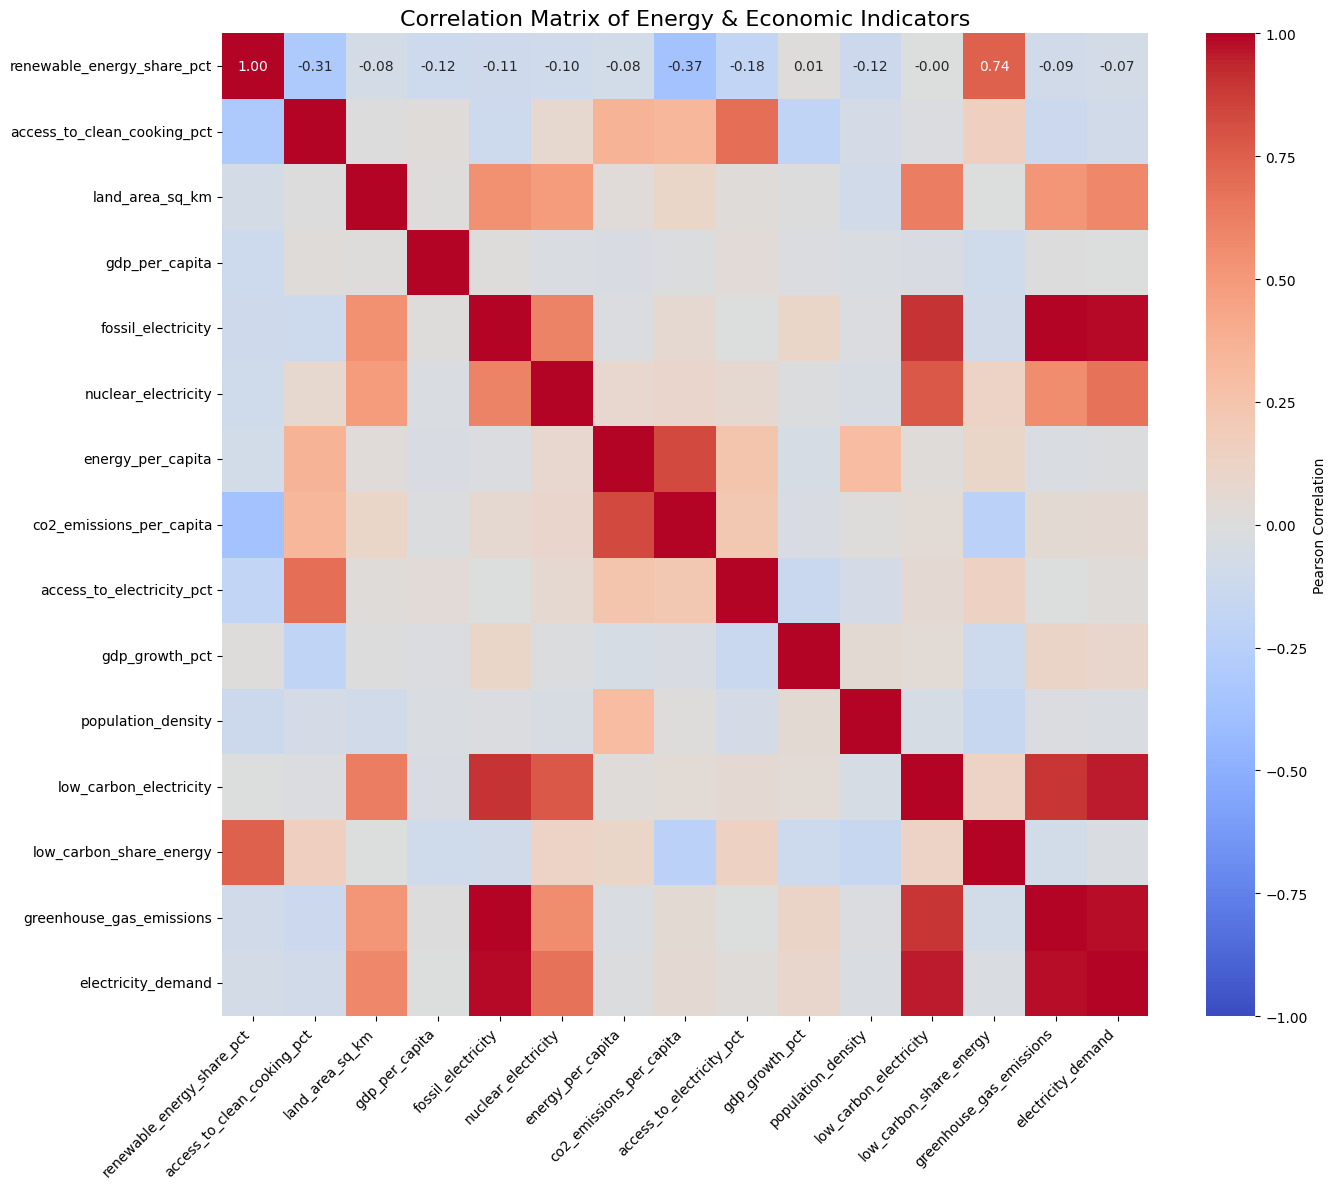

Heatmap saved to correlation_heatmap.png

--- Checking Multicollinearity (VIF) ---
Variables with VIF > 10 (Consider dropping/transforming these):
                   Variable         VIF
         electricity_demand 6540.638115
         fossil_electricity 4475.755767
     low_carbon_electricity  706.570949
   greenhouse_gas_emissions  353.682686
  access_to_electricity_pct  110.599454
access_to_clean_cooking_pct   98.560417
          energy_per_capita   26.137739
   co2_emissions_per_capita   25.972928
    low_carbon_share_energy   12.780547
 renewable_energy_share_pct   11.340103

--- Checking Factor Analysis Prerequisites ---
Bartlett's Test P-value: 0.0
  -> SUCCESS: Variables are correlated enough for Factor Analysis.

Overall KMO Score: 0.560
  -> WARNING: KMO score is too low. You may need to drop variables with low individual KMOs.

Variables with the lowest KMO scores (< 0.50 should be dropped):
                   Variable      KMO
         population_density 0.108146
          

/opt/anaconda3/lib/python3.11/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [7]:
# 1. Load your newly cleaned dataset
cleaned_df = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')
    
# 2. Initialize the Data Exploration class
explorer = DE(cleaned_df)
    
# 3. Run all analyses
explorer.run_all()

## Step 3: Factor Analysis and Clustering

4. FactorAnalysisPrep: Takes the cleaned panel, isolates only the structural macro-variables (GDP, basic energy access, energy intensity), handles their outliers/skewness, standardizes them, and validates the KMO/Bartlett scores.

Outputs: X_for_FA; y_for_Model

5. CountryProfiler: Takes X_scaled_for_FA, runs the factor analysis to extract latent dimensions, clusters the countries into regimes (e.g., Developed vs. Developing), and attaches these Profile IDs back onto the original Cleaned_Analysis_Ready_Panel.csv. 

Outputs: Final_Panel_With_Profiles.csv; Cluster_Optimization.png

In [8]:
from utils import FactorAnalysisPrep

In [9]:
# 1. Load the data
df_clean = pd.read_csv('Cleaned_Analysis_Ready_Panel.csv')

# 2. Initialize the prep class
prep = FactorAnalysisPrep(dataframe=df_clean, target_variable='renewable_energy_share_pct')

# 3. RUN IT ALL IN ONE LINE!
X_for_FA, y_for_Model = prep.run_pipeline()

# Optional: Save it so you don't have to run it again
# X_for_FA.to_csv('Factor_Analysis_Ready_X.csv', index=False)

Initialized with 6 highly curated features.

--- Handling Outliers ---
Outliers capped successfully.

--- Handling Skewed Distributions ---
Log transformed skewed variables: ['access_to_electricity_pct', 'access_to_clean_cooking_pct', 'gdp_per_capita', 'energy_per_capita', 'low_carbon_share_energy']

--- Standardizing Variables ---
Data standardization complete.

--- Final VIF Check ---
                   Variable      VIF
access_to_clean_cooking_pct 2.624725
  access_to_electricity_pct 1.963460
          energy_per_capita 1.852127
             gdp_growth_pct 1.069477
    low_carbon_share_energy 1.067504
             gdp_per_capita 1.036422

--- Factor Analysis Prerequisites ---
Bartlett's Test P-value: 2.7163367495541405e-210
  -> SUCCESS: Variables are correlated enough for Factor Analysis.
Overall KMO Score: 0.665
  -> SUCCESS: KMO score is adequate for Factor Analysis.

Individual KMO Scores (>0.5 is good):
                   Variable  Individual_KMO
    low_carbon_share_energy    

In [10]:
from utils import CountryProfiler


--- Step 1: Factor Analysis ---
Optimal number of latent factors found (Eigenvalue > 1): 3

Factor Loadings (What each factor represents):
                             Factor_1  Factor_2  Factor_3
access_to_electricity_pct        0.74      0.09      0.01
access_to_clean_cooking_pct      0.93      0.06     -0.14
gdp_per_capita                  -0.02      0.02      0.70
gdp_growth_pct                  -0.20     -0.10      0.17
energy_per_capita                0.70     -0.11     -0.05
low_carbon_share_energy          0.02      1.00     -0.02

--- Step 2: Determining Optimal Clusters ---
Cluster optimization plot saved as 'Cluster_Optimization.png'.
Recommended number of clusters (Max Silhouette Score): 2

--- Step 3: Fitting K-Means (K=2) ---

Median Characteristics of Each Profile (Unscaled Values):
                 access_to_electricity_pct  access_to_clean_cooking_pct  \
Profile_Cluster                                                           
0                                    100

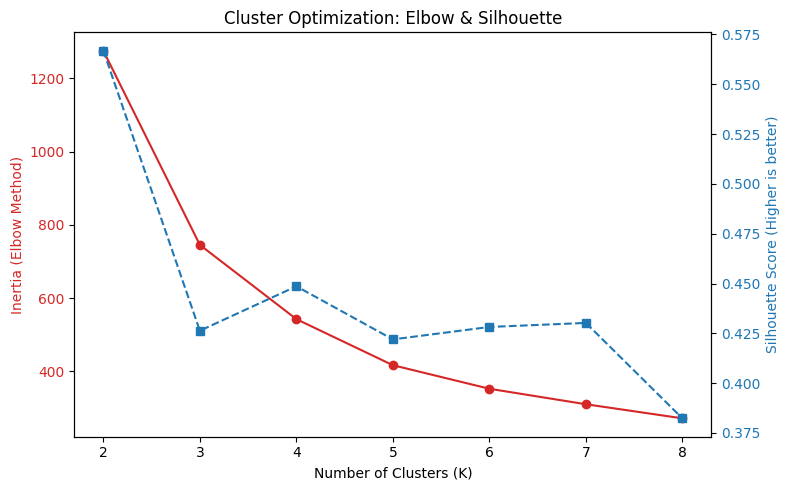

In [ ]:
profiler = CountryProfiler(X_scaled=X_for_FA, original_df=df_clean)

# Run the pipeline
final_panel_with_profiles = profiler.run_profiling()

# Save the finalized dataset!
final_panel_with_profiles.to_csv("Final_Panel_With_Profiles.csv", index=False)

## Step 4: Time Series Analysis

6. TimeSeriesAnalyzer: Takes Final_Panel_With_Profiles.csv and specifically analyzes the renewable_energy_share_pct over time. It plots the macro-trends per cluster, tests for stationarity (ADF Test), checks autocorrelation (stickiness), and measures global policy convergence.

Outputs: TSA_Autocorrelation.png; TSA_Convergence.png; TSA_Macro_Trends.png

In [12]:
from utils import TimeSeriesAnalyzer

Initialized Time Series Analyzer for 'renewable_energy_share_pct' (2012 - 2021)

--- 1. Macro Trend Analysis ---


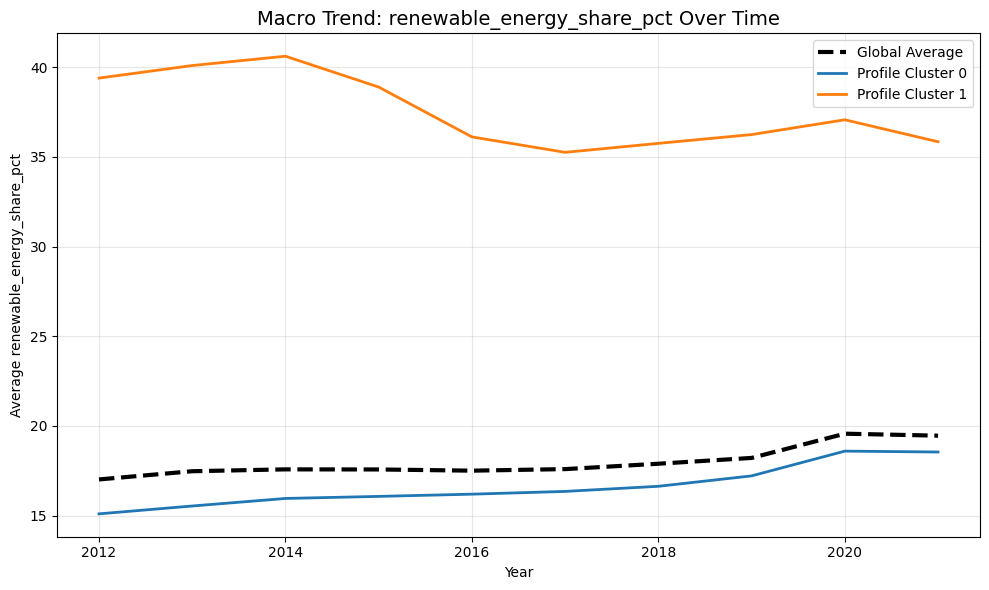

Saved 'TSA_Macro_Trends.png'.

--- 2. Stationarity Test (Augmented Dickey-Fuller) ---
ADF Statistic: 0.4416
P-value: 0.9830
Conclusion: The series is NON-STATIONARY (Fail to reject null hypothesis).
Econometric Impact: The variable has a time-trend. You should include 'Year' fixed effects in your final model, or use the Year-over-Year change (first difference).

--- 3. Autocorrelation Analysis (Inertia) ---


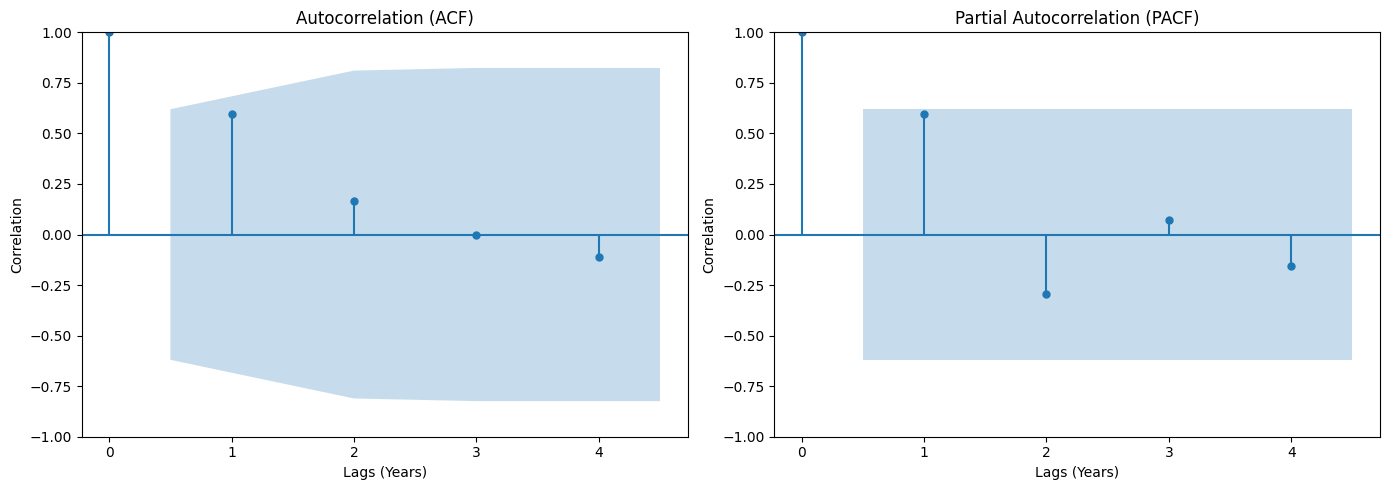

Saved 'TSA_Autocorrelation.png'.
Interpretation: If the bar at Lag 1 is very tall (close to 1.0), renewable energy adoption is highly path-dependent.

--- 4. Policy Convergence Analysis ---


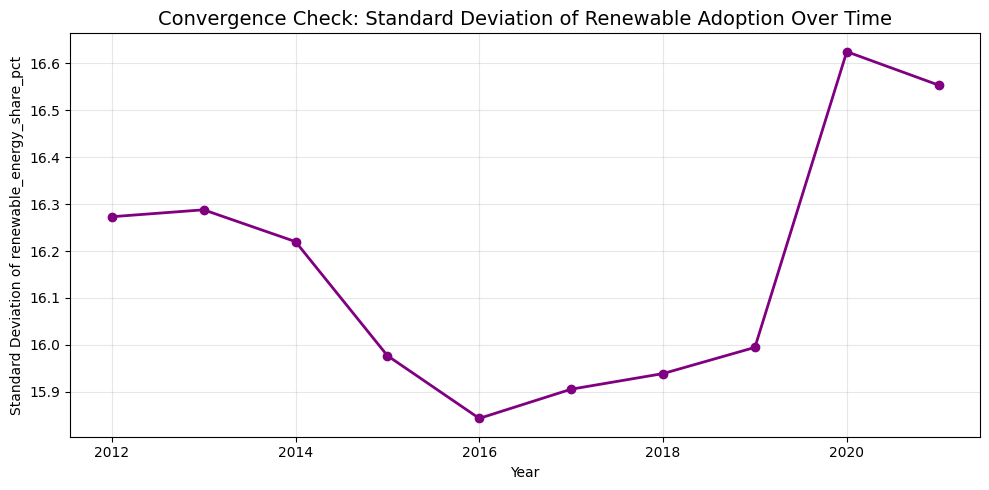

Saved 'TSA_Convergence.png'.
Conclusion: DIVERGENCE detected. The gap between leading and lagging countries is widening.

Time Series Analysis Complete!


In [13]:
# Load your final clustered dataframe
final_df = pd.read_csv("Final_Panel_With_Profiles.csv")

# Initialize and run
ts_analyzer = TimeSeriesAnalyzer(dataframe=final_df, target_var='renewable_energy_share_pct')
ts_analyzer.run_all()

## Step 5: Econometrics Modeling

7. AdvancedDataProcessing: Feed Final_Panel_With_Profiles.csv into this class. It looks at your broader set of variables, caps their outliers, logs the heavily skewed distributions, and automatically drops variables that exceed the 0.80 correlation threshold.

Outputs: transformed_df; dynamic_vars

8. AdvancedPanelModeler: You feed the transformed dataset and the dynamic variable list from Step 7 into this final class. It then runs the Papke & Wooldridge (2008) Fractional Probit or the Ramalho (2017) Log-Odds Fixed Effects separately for Cluster 0 and Cluster 1.

Outputs: table_c0; table_c1

In [14]:
from utils import AdvancedDataProcessing

In [15]:
# 1. Load the data that has the Cluster Profiles attached
profiled_df = pd.read_csv("Final_Panel_With_Profiles.csv")

# 2. Run Step 7
processor = AdvancedDataProcessing(dataframe=profiled_df, target_variable='renewable_energy_share_pct')
transformed_df, dynamic_vars = processor.run_pipeline()

Initialized AdvancedDataProcessing.
Dynamically detected 14 independent variables from the cleaned panel.

--- Handling Outliers (Winsorizing at 1% and 99%) ---

--- Applying Log Transformations to Skewed Variables ---
Log transformed variables: ['access_to_clean_cooking_pct', 'land_area_sq_km', 'gdp_per_capita', 'fossil_electricity', 'nuclear_electricity', 'energy_per_capita', 'co2_emissions_per_capita', 'access_to_electricity_pct', 'population_density', 'low_carbon_electricity', 'low_carbon_share_energy', 'greenhouse_gas_emissions', 'electricity_demand']

--- Dropping Highly Correlated Variables (> 0.8) ---
Variables dropped due to multicollinearity: ['co2_emissions_per_capita', 'greenhouse_gas_emissions', 'electricity_demand']
Surviving independent variables for regression: 11

Data Processing Complete! Ready for Econometrics.


In [18]:
from utils import AdvancedPanelModeler
from utils import generate_comparison_table

In [19]:
# Initialize Step 8: The Econometric Modeler
modeler = AdvancedPanelModeler(
    dataframe=transformed_df,       # Fed directly from Step 7
    independent_vars=dynamic_vars,  # Fed directly from Step 7
    target_var='renewable_energy_share_pct',
    cluster_var='Profile_Cluster'
)

# --- Analyze Profile Cluster 0 ---
pw_c0 = modeler.run_pw2008_cre_fractional_probit(cluster_id=0)
ram_c0 = modeler.run_ramalho2017_transformed_fe(cluster_id=0)

# Print the clean comparison table for Cluster 0
table_c0 = generate_comparison_table(pw_c0, ram_c0, cluster_id=0)

# --- Analyze Profile Cluster 1 ---
pw_c1 = modeler.run_pw2008_cre_fractional_probit(cluster_id=1)
ram_c1 = modeler.run_ramalho2017_transformed_fe(cluster_id=1)

# Print the clean comparison table for Cluster 1
table_c1 = generate_comparison_table(pw_c1, ram_c1, cluster_id=1)
    
# Optional: Save tables to CSV for your final thesis write-up
# table_c0.to_csv("Cluster_0_Regression_Results.csv")
# table_c1.to_csv("Cluster_1_Regression_Results.csv")


Initialized AdvancedPanelModeler.
Ready to run econometrics on 11 independent variables.

 PAPKE & WOOLDRIDGE (2008) CRE FRACTIONAL PROBIT: CLUSTER 0

 RAMALHO (2017) TRANSFORMED FIXED EFFECTS: CLUSTER 0


********************************************************************************
 FINAL ECONOMETRIC COMPARISON: PROFILE CLUSTER 0
 Dependent Variable: Renewable Energy Share (%)
********************************************************************************
                                 PW2008 (CRE Probit) Ramalho2017 (Log-Odds FE)
const                                     9.3619                  -20.4675    
access_to_clean_cooking_pct              -0.6915 ***               -0.8691 ***
land_area_sq_km                           0.5142                    3.2100    
gdp_per_capita                            0.2300 ***                0.4567 ***
fossil_electricity                       -0.1825 ***               -0.2996 ***
nuclear_electricity                       0.0024            